# Project: Investigate a Dataset - TMDb Movie Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

# <a id='intro'></a>
## Introduction

### Dataset Description 

#### Overall Stucture
The dataset used in this project consists of a single main table, where each row corresponds to a movie, drawn from The Movie Database (TMDb). There are 10,000+ movies and 21 columns describing identifiers, textual metadata, rating information, and financial performance, in both nominal and inflation-adjusted terms. Because all information is stored in this one table, there are no foreign-key relationships to other tables to manage. Instead, many‑to‑many relationships such as “one movie has multiple genres” or “one movie has multiple cast members” are encoded within multi‑value string columns uumns using a pipe (|) separator.

#### Dataset Fields
The columns in the TMDb dataset appear in the following order:
<ol>
    <li><b>id</b></li>
    Numeric TMDb movie identifier that uniquely identifies each movie in this dataset. It is useful for referencing specific records and for joining with other TMDb‑based data sources if needed.
    <li><b>imdb_id</b></li>
    String identifier for the corresponding title in the Internet Movie Database (IMDb), typically of the form tt0369610. This enables cross‑referencing or merging with external IMDb datasets or APIs.
    <li><b>popularity</b></li>
    A TMDb popularity score summarizing how much attention a movie receives on the platform (based on views, activity, and ratings). This metric is helpful for studying which movies attract more user engagement, beyond just ratings or revenue.
    <li><b>budget</b></li>
    The reported production budget of the movie, in nominal US dollars at the time of release. This is a core variable for investigating how production spending relates to eventual box‑office performance and profitability, but it is not adjusted for inflation.
    <li><b>revenue</b></li>
    The reported worldwide box‑office revenue, also in nominal US dollars. It serves as a direct measure of commercial success and can be combined with "budget" to compute nominal profit.
    <li><b>original_title</b></li>
    The original title of the movie as recorded in TMDb. Although not typically used in quantitative analysis, this column is important for labeling plots and tables and for interpreting which specific movies drive observed patterns.
    <li><b>cast</b></li>
    A pipe‑separated list of main cast members (for example, "Chris Pratt|Bryce Dallas Howard|Irrfan Khan|…"). This column describes the actors associated with each film and can be used to explore questions such as which performers appear most often or whether certain casts correlate with higher revenue or ratings.
    <li><b>homepage</b></li>
    The URL of the movie’s official website, when available. This field is mainly descriptive and often missing, so it is less central for numerical analysis but can be useful for manual lookup or extended contextual information.
    <li><b>director</b></li>
    The name of the movie’s director. This column can support analyses of individual directors’ filmographies and whether some directors consistently receive higher ratings or revenues.
    <li><b>tagline</b></li>
    A short marketing tagline or promotional phrase associated with the movie. Taglines are useful for qualitative exploration or text analysis, but they are frequently missing and are usually not central to basic numerical summaries.
    <li><b>keywords</b></li>
    A pipe‑separated list of descriptive keywords summarizing themes, topics, or elements in the film (for example, "monster|dna|tyrannosaurus rex|velociraptor|island"). These keywords can support content‑based exploration or recommendation, though they typically require additional text processing to analyze systematically.
    <li><b>overview</b></li>
    A brief textual synopsis of the movie’s plot. This field provides narrative context and is most relevant for natural language processing or qualitative inspection rather than for basic aggregation and plotting.
    <li><b>runtime</b></li>
    The running time of the movie in minutes. Runtime can be used to explore whether film length relates to user ratings, popularity, or revenue, and to detect or filter out anomalous entries (such as extremely short or zero‑length records).
    <li><b>genres</b></li>
    A pipe‑separated list of genres assigned to the movie (for example, "Action|Adventure|Science Fiction|Thriller"). This is a key descriptive column that allows genre‑based comparisons of average rating, revenue, or inflation‑adjusted profit; it is typically transformed by splitting on | when analyzing individual genres.
    <li><b>production_companies</b></li>
    A pipe‑separated list of production companies that participated in making the film (for example, "Universal Studios|Amblin Entertainment|Legendary Pictures|…"). This column can be used to study which studios or companies are most prolific or most successful financially, though it can be highly granular and sometimes sparse.
    <li><b>release_date</b></li>
    The release date of the movie in month/day/year format (for example, "6/9/15"). This field is often converted into a proper datetime object and used to derive release_year, decades, or seasonal patterns in releases and performance.
    <li><b>vote_count</b></li>
    The total number of user votes (ratings) the movie has received on TMDb. This is important for assessing how reliable the vote_average score may be and for distinguishing niche films with few ratings from widely rated mainstream releases.
    <li><b>vote_average</b></li>
    The mean user rating on a 0–10 scale, based on the votes counted in vote_count. This is the primary measure of audience reception in the dataset and is could be analyzed in relation to genres, budget, release year, and revenue.
    <li><b>release_year</b></li>
    The release year extracted from the release date, stored as an integer (for example, 2015). This column is convenient for grouping movies by year and examining trends in ratings, production budgets, and revenues over time without additional date parsing.
    <li><b>budget_adj</b></li>
    The inflation‑adjusted production budget, expressed in 2010 US dollars. By controlling for inflation, this field enables fair comparisons of real production spending across movies released in different years and decades.
    <li><b>revenue_adj</b></li>
    The inflation‑adjusted worldwide box‑office revenue, also expressed in 2010 US dollars. This adjusted revenue is crucial for comparing financial performance across time on a consistent monetary basis and for computing inflation‑adjusted profit measures.
</ol>

#### Tables and Relationships
All of the columns above belong to a single table, and no additional tables are provided in the dataset. There are therefore no explicit one‑to‑many or many‑to‑many relationships between separate tables to document; instead, multi‑valued relationships (such as one‑movie‑to‑many‑genres or one‑movie‑to‑many‑cast‑members) are encoded inside the <b>genres, cast, keywords, and production_companies</b> columns using pipe‑separated strings.
    
### Question for Analysis
#### Question: How do a movie's real (inflation-adjusted) budget, runtime and genre relate to its average user rating on TMDb?
In this project, we investigate what factors are associated with higher user ratings for movies on TMDb. Specifically, we examine how a movie’s inflation‑adjusted production budget (budget_adj), runtime, and genres relate to its average user rating (vote_average). By focusing on one clear outcome (user rating) and three different types of explanatory variables (financial, structural, and content‑based), we aim to identify which characteristics are most strongly associated with better‑rated films in this dataset.
<ul>
    <li>Dependent Variable: vote_average (user rating on a 0-10 scale)</li>
    <li>Independent Variables:
        <ol>
            <li>budget_adj - inflation adjusted budget in 2010 dollars</li>
            <li>runtime - movie length in minutes</li>
            <li>genres - categorical information capturing the movies genre(s)</li>
        </ol>
</ul>

In [1]:
# Import core analysis libraries
import numpy as np # Numerical computing, arrays, and math operations
import pandas as pd # Data loading, cleaning, manipulation, and analysis

# Import plotting libraries for visualization 
import matplotlib.pyplot as plt # Basic plotting (line, bar, scatter, etc.)
import seaborn as sns # Statistical data visualization built on top of matplotlib

# Configure plotting to display charts inside the Jupyter Notebook
%matplotlib inline 
# Ensures plots appear inline

sns.set(style="whitegrid") # Uses a clean, grid-based style for all Seaborn plots


> **Note**: This project uses pandas DataFrames and Series, along with NumPy arrays and vectorized operations, as the primary data structures for cleaning, transforming, and analyzing the dataset. In keeping with good coding practice, reusable functions will be defined where appropriate to reduce repetition and make the notebook easier to read, maintain, and reproduce.


<a id='wrangling'></a>
## Data Wrangling

### General Properties

In [2]:
# Load the TMDb movies dataset into a pandas DataFrame
df = pd.read_csv("tmdb-movies.csv")

# Checking on the loaded DataFrame
df.head()
df.info()

# Basic structure and size:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Summary stats for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


#### Loading in the TMDb Dataset and Basic Inspection
In this step, we load the TMDb movies dataset from the CSV file into a pandas DataFrame named `df`. Using a DataFrame allows us to leverage pandas’ built‑in functionality for efficient data cleaning, transformation, and analysis rather than working with raw Python lists or dictionaries.

After loading the file, we run a series of quick inspection commands to better understand the structure and contents of the dataset before performing any cleaning. The `df.head()` call displays the first few rows so we can visually confirm that the columns and sample values look reasonable. The `df.info()` output summarizes each column’s data type and the number of non‑null entries, which helps us identify potential issues such as missing values or incorrect data types.

We then print the number of rows and columns using `df.shape` to get a sense of the dataset’s overall size. Finally, `df.describe()` computes summary statistics (such as mean, standard deviation, and quartiles) for the numeric columns. These descriptive statistics can reveal unusual values, potential outliers, and basic distribution characteristics, which will guide the more detailed data‑wrangling and cleaning steps that follow.


#### What the Initial Summary Tells Us
The output from the code cell above gives us a first, high‑level picture of the TMDb movies dataset before any cleaning is applied. The preview from `df.head()` confirms that each row represents a single movie and shows example values for key columns such as titles, genres, runtime, popularity, budget, revenue, and user ratings. The `df.info()` summary reports the column names, data types, and non‑null counts, which lets us see that most columns are loaded as numeric or string types as expected and also reveals where missing values occur in fields like `homepage`, `tagline`, or other optional metadata.

The printed shape (number of rows and columns) tells us the overall size of the dataset, indicating that we are working with a fairly large sample of movies rather than just a handful of examples. Finally, `df.describe()` provides basic descriptive statistics for all numeric columns, such as the range and typical values of `popularity`, `budget`, `revenue`, `runtime`, and rating‑related fields; these statistics can highlight potential outliers (for example, extremely high revenues or runtimes) and give a sense of the scale and variability we will need to account for in later cleaning and analysis steps.


In [3]:
# Count missing values per column
print("Number of Missing Values per Column:")
print(df.isna().sum())
print("_" * 40)

# Percentage of missing values per column
print("Percentage of Missing Values per Column:")
print((df.isna().sum() / len(df)) * 100)
print("_" * 40)

# Check for duplicated rows
print("Number of Duplicated Rows:", df.duplicated().sum())

Number of Missing Values per Column:
id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64
________________________________________
Percentage of Missing Values per Column:
id                       0.000000
imdb_id                  0.092030
popularity               0.000000
budget                   0.000000
revenue                  0.000000
original_title           0.000000
cast                     0.699429
homepage             

#### Identifying Missing Values and Duplicate Records
The previous code cell takes a first systematic look at data quality issues in the dataset, focusing on missing values and duplicate rows. The first section calls `df.isna().sum()` to count how many entries are missing in each column, which helps us see which variables (such as optional text fields) may require special handling before analysis. The second section converts these counts into percentages relative to the total number of rows, giving a clearer sense of how severe the missingness is for each column.

Finally, `df.duplicated().sum()` checks how many rows in the dataset are exact duplicates of earlier rows. Identifying duplicates at this stage is important because repeated records can bias summary statistics and any later analysis if they are not addressed. At this point, we are only diagnosing these issues, not modifying the data; the results will guide the cleaning decisions we make in subsequent steps.

In [4]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.



### Data Cleaning

#### Removing Duplicate Movie Records
Before analyzing relationships in the data, we first remove any exact duplicate rows. Duplicate entries can occur when the same movie is recorded more than once with identical values across all columns. If left in place, these repeated records would overweight certain movies and bias summary statistics and visualizations. At this point we are only dropping *fully* duplicated rows; we are not yet checking for more subtle duplicates (such as the same title with slightly different metadata).

In [5]:
# Number of duplicated rows before cleaning
dup_count_before = df.duplicated().sum()
print("Duplicated rows before drop:", dup_count_before)

# Drop duplicated rows in-place
df.drop_duplicates(inplace=True)

# Confirm how many duplicates remain
dup_count_after = df.duplicated().sum()
print("Duplicated rows after drop:", dup_count_after)
print("New shape after dropping duplicates:", df.shape)

Duplicated rows before drop: 1
Duplicated rows after drop: 0
New shape after dropping duplicates: (10865, 21)


#### Step 2: Flag invalid zero values in key numeric columns
In the raw dataset, some movies have a budget or revenue recorded as zero. For real, commercially released movies, a *true* production budget or worldwide revenue of exactly zero is extremely unlikely. Instead, zeros in these fields must be placeholders indicating that the value is unknown or was not recorded.To reflect this, we replace zeros in `budget`, `revenue`, `budget_adj`, and `revenue_adj` with `NaN`. Treating these as missing rather than genuine zeros prevents them from distorting averages, correlations, and other numeric summaries in later analysis.

In [6]:
# Replace impossible zero values in budget/revenue fields with NaN

# Columns in which a zero is likely to mean "missing"
zero_cols = ["budget", "revenue", "budget_adj", "revenue_adj"]

for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"Number of zeros in {col} before replacement:", zero_count)
    
    # Replace zeros with NaN
    df[col] = df[col].replace(0, np.nan)
    
    zero_count_after = (df[col] == 0).sum()
    print(f"Number of zeros in {col} after replacement:", zero_count_after)
    print("-" * 40)

Number of zeros in budget before replacement: 5696
Number of zeros in budget after replacement: 0
----------------------------------------
Number of zeros in revenue before replacement: 6016
Number of zeros in revenue after replacement: 0
----------------------------------------
Number of zeros in budget_adj before replacement: 5696
Number of zeros in budget_adj after replacement: 0
----------------------------------------
Number of zeros in revenue_adj before replacement: 6016
Number of zeros in revenue_adj after replacement: 0
----------------------------------------


#### Drop rows missing essential analysis variables
Our main research question focuses on how a movie’s inflation‑adjusted budget, runtime, and genre relate to its average user rating. For that reason, we need complete information in at least the following columns: `vote_average` (dependent variable), `budget_adj`, `runtime`, and `genres` (independent variables). In this step, we drop any rows that are missing values in one or more of these essential columns. This reduces the total number of movies slightly but ensures that every remaining record contains all the core variables required for our analysis.

In [7]:
# Drop rows with missing values in essential columns
essential_cols = ["vote_average", "budget_adj", "runtime", "genres"]

# Number of rows before dropping
rows_before = df.shape[0]

# Drop rows with NaN in any of the essential columns
df = df.dropna(subset=essential_cols)

rows_after = df.shape[0]
print("Rows before dropping missing essentials:", rows_before)
print("Rows after dropping missing essentials:", rows_after)
print("Number of rows removed:", rows_before - rows_after)

Rows before dropping missing essentials: 10865
Rows after dropping missing essentials: 5168
Number of rows removed: 5697


#### Re-check missing values after basic cleaning
After removing duplicate rows, converting zero budgets/revenues to missing, and dropping rows without essential variables, we briefly reassess missingness. This helps confirm that the key analysis columns are now complete, while less critical columns (such as `homepage`, `tagline`, or `keywords`) may still contain nulls. These remaining missing values can often be left as‑is or handled selectively later, depending on whether they are needed for any additional questions.

In [8]:
# Quick missing-value summary after cleaning
print("Remaining missing values per column (post-cleaning):")
print(df.isna().sum())

Remaining missing values per column (post-cleaning):
id                         0
imdb_id                    1
popularity                 0
budget                     0
revenue                 1314
original_title             0
cast                      11
homepage                3461
director                   4
tagline                  615
keywords                 331
overview                   0
runtime                    0
genres                     0
production_companies     136
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj             1314
dtype: int64


### Data Wrangling Summary 
In the data wrangling phase, we prepared the raw TMDb movies dataset for analysis by addressing a few key structural and quality issues. First, we inspected the DataFrame to understand its columns, data types, and patterns of missingness, and then removed any fully duplicated rows so that no movie was counted more than once in our analysis. Next, we treated zero values in the budget and revenue fields (both nominal and inflation‑adjusted) as missing data, since a true budget or worldwide revenue of exactly zero is unrealistic and would indicate that the value was not recorded.

Because our main research question focuses on how a movie’s inflation‑adjusted budget, runtime, and genre relate to its average user rating, we then dropped rows that were missing any of these essential variables, leaving us with a consistent set of movies that all contain the core information needed for our analysis. Less critical descriptive columns, such as homepage URLs, taglines, and keywords, were left as‑is even if they contained missing values, since they are not required for the primary question we aim to answer. As a result, the cleaned dataset is smaller than the original but better structured, with duplicates removed and implausible values handled in a way that reduces their impact on subsequent exploratory analysis.


<a id='eda'></a>
## Exploratory Data Analysis

### Research Question 1: How do a movie's real (inflation-adjusted) budget, runtime and genre relate to its average user rating on TMDb?

### Exploration of User Ratings 
We begin the exploratory analysis by looking at the overall distribution of user ratings (`vote_average`). Since this is our dependent variable, understanding its typical range, center, and spread is essential before relating it to other factors. A histogram provides a visual overview of how ratings are distributed across movies, while summary statistics (mean, median, and standard deviation) describe the central tendency and variability numerically.

Summary statistics for vote_average:
count    5168.000000
mean        6.032895
std         0.883203
min         1.500000
25%         5.500000
50%         6.100000
75%         6.600000
max         8.400000
Name: vote_average, dtype: float64
________________________________________


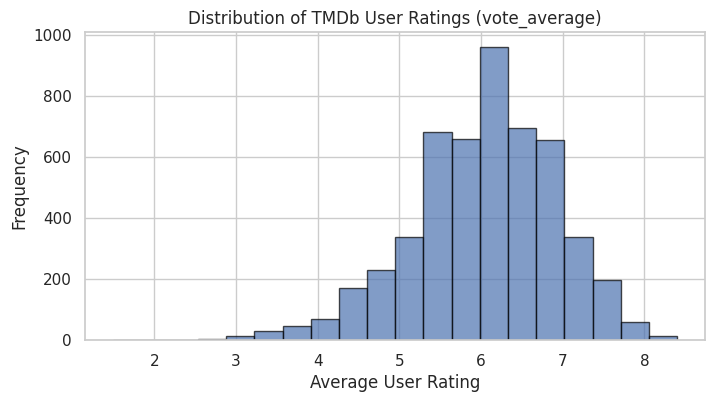

In [9]:
# Distribution of User Ratings

# Summary statistics for vote_average
print("Summary statistics for vote_average:")
print(df["vote_average"].describe())
print("_" * 40)

# Histogram of vote_average using pandas' built-in plotting
ax = df["vote_average"].plot.hist(
    bins=20,
    figsize=(8, 4),
    alpha=0.7,
    edgecolor="black"
)
ax.set_title("Distribution of TMDb User Ratings (vote_average)")
ax.set_xlabel("Average User Rating")
plt.show()

### Exploration of Runtime
Next, we examine the distribution of movie runtimes. This helps us understand what counts as a “typical” movie length in this dataset and whether there are extreme short or long films that might affect our analysis. A histogram again shows the shape of the distribution, and summary statistics like the median and quartiles indicate typical runtimes and the degree of variation.

Summary statistics for runtime (minutes):
count    5168.000000
mean      107.103135
std        22.806717
min         0.000000
25%        93.000000
50%       103.000000
75%       117.000000
max       540.000000
Name: runtime, dtype: float64
________________________________________


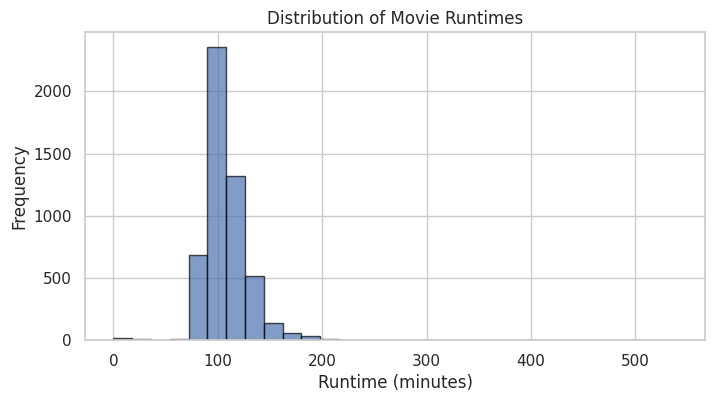

In [10]:
# Distribution of Runtime
print("Summary statistics for runtime (minutes):")
print(df["runtime"].describe())
print("_" * 40)

ax = df["runtime"].plot.hist(
    bins=30,
    figsize=(8, 4),
    alpha=0.7,
    edgecolor="black"
)
ax.set_title("Distribution of Movie Runtimes")
ax.set_xlabel("Runtime (minutes)")
plt.show()

### Exploration of Inflation-Adjusted Budgets
Since one of our main predictors is the inflation‑adjusted budget (`budget_adj`), we also inspect its distribution. Movie budgets often have a long right tail, with a small number of very expensive productions, so looking at both summary statistics and a histogram helps us see how skewed this variable is and whether we might need to be cautious about outliers in later analysis.

Summary statistics for budget_adj (2010 dollars):
count    5.168000e+03
mean     3.689620e+07
std      4.196188e+07
min      9.210911e-01
25%      8.102293e+06
50%      2.272271e+07
75%      5.008384e+07
max      4.250000e+08
Name: budget_adj, dtype: float64
________________________________________


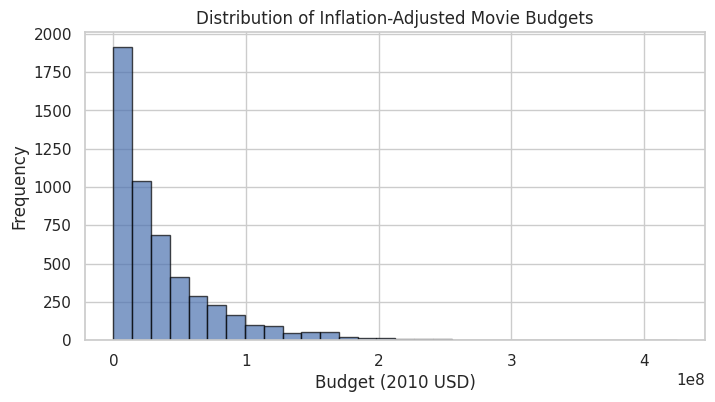

In [11]:
# Distribution of inflation-adjusted budgets
print("Summary statistics for budget_adj (2010 dollars):")
print(df["budget_adj"].describe())
print("_" * 40)

ax = df["budget_adj"].plot.hist(
    bins=30,
    figsize=(8, 4),
    alpha=0.7,
    edgecolor="black"
)
ax.set_title("Distribution of Inflation-Adjusted Movie Budgets")
ax.set_xlabel("Budget (2010 USD)")
plt.show()

### Bivariate Relationship - Budget vs. User Ratings
We now explore how a movie’s inflation‑adjusted budget relates to its average user rating. A scatter plot of `budget_adj` versus `vote_average` lets us visually inspect whether higher‑budget films tend to receive higher ratings or whether the relationship is weak. Because budgets are often highly skewed, we also compute the Pearson correlation coefficient as a simple numeric summary of the linear relationship between these two variables. To reduce repetition and improve readability, the two scatterplot analyses below use a reusable helper function that computes the correlation and produces a labeled scatterplot.

In [12]:
# Helper function for scatterplots with correlation output
def plot_scatter_with_corr(df, x_col, y_col, title, xlabel, ylabel):
    corr_value = df[x_col].corr(df[y_col])
    print(f"Correlation between {x_col} and {y_col}: {corr_value}")
    print("_" * 40)

    plt.figure(figsize=(8, 5))
    plt.scatter(df[x_col], df[y_col], alpha=0.4)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

Correlation between budget_adj and vote_average: 0.11177854105770653
________________________________________


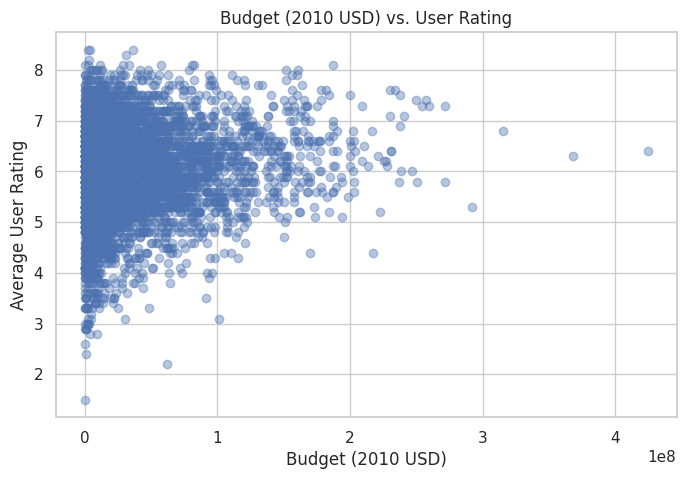

In [13]:
# Bivariabte relationship between budget_adj and vote_average

# Compute correlation (ignoring missing values) using helper UDF
plot_scatter_with_corr(
    df,
    x_col="budget_adj",
    y_col="vote_average",
    title="Budget (2010 USD) vs. User Rating",
    xlabel="Budget (2010 USD)",
    ylabel="Average User Rating"
)

### Bivariate Relationship - Runtime vs. User Rating
We also examine whether movie length has any clear association with user ratings. To do this, we combine a scatter plot of `runtime` against `vote_average` with the corresponding correlation coefficient. This helps us see whether longer movies are generally better rated, worse rated, or if runtime has little apparent effect on ratings.

Correlation between runtime and vote_average: 0.3328660441997443
________________________________________


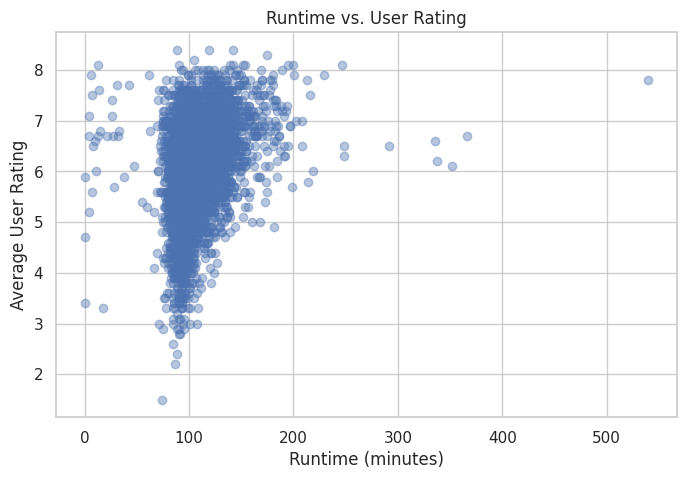

In [14]:
# Relationship between runtime and vote_average using helper UDF
plot_scatter_with_corr(
    df,
    x_col="runtime",
    y_col="vote_average",
    title="Runtime vs. User Rating",
    xlabel="Runtime (minutes)",
    ylabel="Average User Rating"
)

### Multivariate View - User Ratings by Genre
To avoid bias from movies that belong to multiple genres, we first split the pipe‑separated `genres` strings into lists, then use `explode` to create one row per (movie, genre) pair. We then group by this genre column to compute average user ratings per genre using vectorized pandas operations, ensuring that each movie contributes to all of its genres rather than just the first one.

Average user rating by genre (each movie counted in all its genres):
genre
Documentary        6.756250
History            6.524044
War                6.500000
Music              6.365089
Animation          6.355769
Drama              6.295553
Western            6.217568
Crime              6.215067
Romance            6.122416
Mystery            6.062500
Family             6.024857
Adventure          6.008278
Fantasy            5.954724
Comedy             5.946437
Thriller           5.898537
Foreign            5.894286
Action             5.879272
Science Fiction    5.836377
Horror             5.478170
TV Movie           5.233333
Name: vote_average, dtype: float64
________________________________________


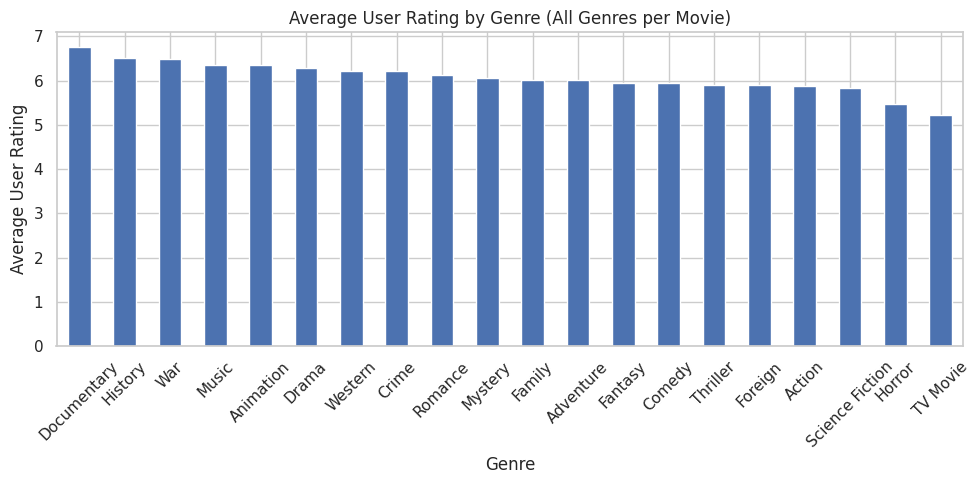

In [15]:
# User ratings across all listed genres (unbiased genre analysis)

# Split the pipe-separated genres into lists
df["genre_list"] = df["genres"].str.split("|")

# Explode so each row has exactly one genre
df_genres = df.explode("genre_list")

# Rename for clarity
df_genres = df_genres.rename(columns={"genre_list": "genre"})

# Compute average rating by genre across the exploded data
genre_rating = (
    df_genres
    .groupby("genre")["vote_average"]
    .mean()
    .sort_values(ascending=False)
)

print("Average user rating by genre (each movie counted in all its genres):")
print(genre_rating)
print("_" * 40)

# Bar plot of average rating by genre (using pandas' plot)
ax = genre_rating.plot(
    kind="bar",
    figsize=(10, 5),
    rot=45
)
ax.set_title("Average User Rating by Genre (All Genres per Movie)")
ax.set_xlabel("Genre")
ax.set_ylabel("Average User Rating")
plt.tight_layout()
plt.show()

### Exploratory Data Analysis Summary
The univariate exploration of user ratings (`vote_average`) shows that most movies in the dataset receive moderate to fairly positive ratings. The histogram indicates a clear concentration of ratings between roughly 5 and 8 on the 0–10 scale, with relatively few movies at the very low or very high ends.

The summary statistics confirm this impression: the mean and median ratings lie in the mid-to-high range, suggesting that extremely poorly rated or exceptionally highly rated movies are comparatively rare in this sample.

Looking at runtimes, the distribution is centered around common feature-length durations, with most movies clustering roughly between 90 and 130 minutes. The descriptive statistics show a reasonable spread but also hint at a few unusually short or very long films, which appear as tails in the histogram; these outliers are worth keeping in mind but do not dominate the overall distribution. Inflation-adjusted budgets (`budget_adj`) display the expected heavy right skew: a large number of relatively modestly funded films and a small number of very expensive blockbusters, resulting in a mean that is noticeably higher than the median.

When we examine the relationship between budget and user ratings, the scatter plot and correlation coefficient suggest only a weak linear association between `budget_adj` and `vote_average`. High-budget movies do not consistently receive higher ratings, and well-rated films can be found across a broad range of budgets, implying that spending more money does not consistently guarantee a better reception from viewers. A similar pattern emerges for runtime: the correlation between `runtime` and `vote_average` is small, and the scatter plot shows that both short and long movies can achieve a wide range of ratings. This indicates that, on their own, neither budget nor runtime is a strong predictor of how highly a movie is rated.

Genre, however, appears to introduce more structure into the ratings. To avoid bias from assigning each movie to only its first listed genre, the `genres` column was split into lists and then expanded using pandas' vectorized `explode` method so that each movie contributes to all of its listed genres. The resulting bar chart of average `vote_average` by genre reveals noticeable differences between genres, with some genres tending to have higher mean ratings than others. Although the dataset does not allow us to claim that genre *causes* higher or lower ratings, these patterns show that genre is a meaningful factor to consider when interpreting how movies are rated on TMDb.

<a id='conclusions'></a>
## Conclusions

This analysis examined how a movie’s inflation-adjusted budget, runtime, and genre relate to its average user rating on TMDb. Overall, the results suggest that user ratings are only weakly associated with budget and runtime, while clearer differences appear across genres. Most movies in the cleaned dataset received ratings in the middle to upper part of the 0–10 scale, indicating that extremely low- or extremely high-rated films are relatively uncommon.

The exploratory analysis showed that movie runtimes are generally concentrated around standard feature-length durations, while inflation-adjusted budgets are strongly right-skewed, with a small number of very expensive films and many more modestly budgeted ones. Scatterplots and correlation measures indicated that neither higher budgets nor longer runtimes consistently correspond to higher user ratings. In other words, movies with strong ratings can be found across a wide range of budgets and runtimes, so these two variables do not appear to be strong predictors of audience ratings on their own.

Genre showed more noticeable variation in relation to ratings than the numeric variables examined. To avoid bias from assigning each movie to only its first listed genre, the `genres` column was split into lists and expanded using pandas' vectorized `explode` method so that each movie contributes to all of its listed genres. After grouping by this per-genre view, the average rating differed across categories, suggesting that some genres tend to receive higher typical ratings than others within this dataset. However, this finding should be interpreted as descriptive rather than causal, since the analysis was exploratory and no formal statistical tests were performed.

Several limitations should be kept in mind when interpreting these results. First, the dataset contains popular movies from TMDb rather than a random sample of all films, so the findings may not generalize to all movies. Second, the analysis used only a limited number of variables and did not account for other factors that may influence ratings, such as release year, franchise status, marketing, critic reception, or star power. Third, even with the improved handling of multi-genre films, the genre analysis still simplifies a complex creative landscape and does not model interactions among genres or with other variables.

Additional research could improve this analysis by incorporating more explanatory variables, expanding the modeling of multi-genre combinations, or comparing TMDb ratings with other sources such as IMDb or critic review data. More advanced statistical methods could also be applied to test whether the observed relationships remain meaningful when several variables are considered together. Within the scope of this project, the findings support the conclusion that genre appears to have a more noticeable relationship with user ratings than either inflation-adjusted budget or runtime, while budget and runtime show only weak associations with audience ratings.

In [16]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 738081 bytes to Investigate_a_Dataset.html
